# 커뮤니티 지구 시스템 모델 (CESM) 소개

이 노트북은 알바니 대학교의 [Brian E. J. Rose](https://www.atmos.albany.edu/facstaff/brose/)가 작성한 [기후 실험실](https://brian-rose.github.io/ClimateLaboratoryBook)의 일부입니다.

## CESM 소개

### 무엇인가요?

*   CESM은 IPCC 과정의 일부로 사용되는 몇 안 되는 복합 결합 전지구 기후 모델(GCMs) 중 하나입니다.
*   기후 과학자들과 소프트웨어 엔지니어들로 구성된 그룹에 의해 NCAR (볼더, 콜로라도)에서 개발 및 유지 관리됩니다.
*   “커뮤니티”는 코드가 오픈 소스이며, 다양한 사용자들이 새로운 부분을 기여한다는 사실을 의미합니다.

저는 제 연구에서 CESM을 사용합니다. 저희는 이 강좌에서 CESM을 사용할 예정입니다. CESM에 대한 더 많은 정보는 다음과 같습니다:

https://www.cesm.ucar.edu/models/

### CESM의 주요 구성 요소:

저희는 CESM 버전 1.2에서 생성된 결과물을 사용할 것이며, 여기에는 다음 구성 요소들이 포함됩니다:

 - 대기 모델 (AGCM)
     - 커뮤니티 대기 모델 (CAM)
 - 해양 모델 (OGCM)
     - 병렬 해양 프로그램 (POP)
 - 육상 표면 모델
     - 커뮤니티 육상 모델 (CLM)
 - 해빙 모델
     - 커뮤니티 해빙 코드 (CICE)

이 소프트웨어는 다소 모듈식으로 구성되어 있어, 당면한 과학적 문제의 성격과 사용 가능한 컴퓨터 성능에 따라 다양한 하위 모델들을 함께 조합할 수 있습니다.

우리가 기후 모델에서 해양을 나타내는 다양한 방식에 대한 이 개략도를 이전에 살펴보았음을 기억해 봅시다:

## CESM을 이용한 우리의 수치 실험

### 대기

- 수평 해상도는 약 2도 위도/경도
- 대기 대순환 모델 (AGCM)은 다음과 같은 기본 방정식을 풉니다:
    - 운동량, 질량, 에너지, 물 보존 방정식, 상태 방정식
- 2도 해상도에서는 **종관 규모 동역학 (synoptic-scale dynamics)**을 해결합니다.
    - 폭풍 경로 및 저기압.
- 우리는 중규모 (mesoscale) 및 그보다 작은 규모의 현상은 해결하지 못합니다.
    - 뇌우, 개별 대류 현상, 구름
- 이 모든 현상들은 매개변수화 (parameterized) 되어야 합니다.
- 모델은 또한 복사 전달 (radiative transfer) 방정식을 풉니다. 여기에는 다음 사항이 고려됩니다:
    - 대기의 조성과 다양한 기체의 흡수 특성
    - 구름의 복사 효과.

### 해빙

- 해상도 1도.
- 열역학 (에너지, 물, 염분 보존)
    - 동결 및 융해 결정
- 역학 (운동량 방정식)
    - 해빙의 이동 및 변형 결정.
- 복잡성! 해빙은 유체와 고체의 혼합물과 같은 특성을 가집니다.

### 지표 모델(Land surface model)

*   대기(atmosphere)와 동일한 해상도를 가집니다.
*   사전 정의된 식생 유형(vegetation types)에 기반하여 열, 물, 운동량(마찰)의 표면 플럭스(surface fluxes)를 결정합니다.
*   실제로 어떻게 작동하는지에 대해서는 잘 모릅니다!
*   누군가 학기 프로젝트(term project)를 위해 깊이 탐구하기에 훌륭한 주제입니다.

### 해양

- 해빙(sea ice)과 동일한 1도 격자(grid)를 사용합니다.
- 대기 및 해빙과 열, 물, 운동량을 교환합니다.
- 육지 표면(강)으로부터 유출수(runoff)를 받습니다.
- 해류에 대한 완전한 3차원 시뮬레이션을 수행합니다.

### 실험 설정

모델에는 현실적인 대기 구성, 현실적인 태양 복사 등이 주어집니다.

우리는 기준 시뮬레이션(baseline simulation)을 얻기 위해 **산업화 이전 대조군 실행(preindustrial control run)**을 수행하고, (모델에 내부 변동성(internal variability)이 있어 매년 조금씩 다르기 때문에) **수년간의 평균을 취합니다.**

그리고 나서 (나중에) 우리는 무언가를 변경할 것입니다. 예를 들어, 대기 중 CO$_2$를 두 배로 늘리는 것과 같이 말이죠!

그리고 모델이 새로운 평형 상태(equilibrium)로 조정되도록 할 것입니다. 우리가 장난감 에너지 균형 모델(toy energy balance model)에서 했던 것과 똑같이 말이죠.

## xarray를 이용한 입력 데이터 둘러보기

먼저, 통제 실행(control run)에 사용되는 몇 가지 구성 요소를 살펴보겠습니다. **학과 내에 위치한 특별 데이터 서버에서 필요한 모든 데이터가 제공될 것입니다.** 따라서 인터넷에 연결된 어떤 컴퓨터에서든 이 코드를 실행하여 해당 데이터와 상호작용할 수 있습니다.

### 이 노트북의 코드를 실행하려면 인터넷에 연결되어 있어야 합니다 ###

여기 웹 인터페이스를 통해 사용 가능한 데이터를 열람할 수 있습니다:

http://thredds.atmos.albany.edu:8080/thredds/catalog.html

`CESM archive`라는 이름의 이 폴더 안에, 모든 입력 파일이 들어있는 `som_input`이라는 또 다른 폴더를 찾을 수 있습니다.

데이터는 모두 `NetCDF` 파일로 저장되어 있으며, 이는 자체 기술적인 격자 데이터(self-describing gridded data)를 위한 표준 파일 형식입니다.

In [12]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

데이터셋(datasets)을 다루기 위해 [xarray](http://xarray.pydata.org)라는 패키지를 사용할 것입니다. (여기서는 `xr`로 약칭하겠습니다.)

### 경계 조건: 대륙과 지형

여기서는 입력 지형 파일을 불러와 그 내용을 살펴보겠습니다.

이 경우, 우리는 온라인 데이터 서버의 URL을 전달할 것입니다. 나중에 작업을 단순화하기 위해 이 URL을 `datapath`라는 문자열 변수에 저장하겠습니다.

파일은 이제 구글 드라이브(`MyDrive/testdata` 폴더)에서 직접 로드됩니다. 코드를 실행하기 전에 드라이브를 마운트하는 셀을 실행했는지 확인하세요.

In [13]:
# 이 셀은 이제 파일을 업로드하는 대신, 구글 드라이브 경로를 사용합니다. 드라이브가 마운트되었는지 확인하세요.

파일이 성공적으로 업로드되었다면, 이제 `xarray`를 사용하여 이 파일을 열 수 있습니다. 파일 이름이 현재 작업 디렉토리(`/content/`)에 있다고 가정하고 코드를 작성합니다.

In [18]:
# 업로드된 파일 이름 (이제 구글 드라이브에서 직접 로드)
local_file_name = "/content/drive/MyDrive/testdata/USGS-gtopo30_1.9x2.5_remap_c050602.nc"

# 이제 데이터셋을 엽니다.
topo = xr.open_dataset(local_file_name)
topo

<xarray.Dataset> Size: 555kB
Dimensions:       (lat: 96, lon: 144)
Coordinates:
  * lat           (lat) float64 768B -90.0 -88.11 -86.21 ... 86.21 88.11 90.0
  * lon           (lon) float64 1kB 0.0 2.5 5.0 7.5 ... 350.0 352.5 355.0 357.5
Data variables:
    PHIS          (lat, lon) float64 111kB ...
    SGH           (lat, lon) float64 111kB ...
    SGH30         (lat, lon) float64 111kB ...
    LANDFRAC      (lat, lon) float64 111kB ...
    LANDM_COSLAT  (lat, lon) float64 111kB ...
Attributes:
    history:    Written on date: 20050602\ndefinesurf -remap -t /fs/cgd/csm/i...
    make_ross:  true
    topofile:   /fs/cgd/csm/inputdata/atm/cam/topo/USGS-gtopo30_10min_c050419.nc
    gridfile:   /fs/cgd/csm/inputdata/atm/cam/coords/fv_1.9x2.5.nc
    landmask:   /fs/cgd/csm/inputdata/atm/cam2/hrtopo/landm_coslat.nc

In [19]:
topo


<xarray.Dataset> Size: 555kB
Dimensions:       (lat: 96, lon: 144)
Coordinates:
  * lat           (lat) float64 768B -90.0 -88.11 -86.21 ... 86.21 88.11 90.0
  * lon           (lon) float64 1kB 0.0 2.5 5.0 7.5 ... 350.0 352.5 355.0 357.5
Data variables:
    PHIS          (lat, lon) float64 111kB ...
    SGH           (lat, lon) float64 111kB ...
    SGH30         (lat, lon) float64 111kB ...
    LANDFRAC      (lat, lon) float64 111kB ...
    LANDM_COSLAT  (lat, lon) float64 111kB ...
Attributes:
    history:    Written on date: 20050602\ndefinesurf -remap -t /fs/cgd/csm/i...
    make_ross:  true
    topofile:   /fs/cgd/csm/inputdata/atm/cam/topo/USGS-gtopo30_10min_c050419.nc
    gridfile:   /fs/cgd/csm/inputdata/atm/cam/coords/fv_1.9x2.5.nc
    landmask:   /fs/cgd/csm/inputdata/atm/cam2/hrtopo/landm_coslat.nc

`Dataset` 객체는 여러 중요한 속성(attributes)을 가지고 있습니다. 이전에 `netCDF` 데이터를 다뤄본 경험이 있다면, 이 중 많은 부분이 익숙하게 느껴질 것입니다. `xarray` 패키지는 데이터에 대한 매우 강력하고 사용하기 쉬운 인터페이스를 제공합니다.


http://thredds.atmos.albany.edu:8080/thredds/catalog/CESMA/som_input/catalog.html

`xarray.Dataset` 객체 내의 각 변수들은 다음과 같이 접근할 수 있습니다.

In [20]:
topo.PHIS

<xarray.DataArray 'PHIS' (lat: 96, lon: 144)> Size: 111kB
[13824 values with dtype=float64]
Coordinates:
  * lat      (lat) float64 768B -90.0 -88.11 -86.21 -84.32 ... 86.21 88.11 90.0
  * lon      (lon) float64 1kB 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
Attributes:
    long_name:   surface geopotential
    units:       m2/s2
    from_hires:  true
    filter:      remap

### 지형 플로팅

이제 지위 고도(geopotential)를 읽고 2도 격자에 표현된 지구 표면의 지형도를 그려볼 것입니다. 아래 코드는 지형의 다채로운 플롯을 생성합니다. 또한, 완전히 해양으로 덮인 격자점에서는 아무것도 플로팅되지 않도록 육지-해양 마스크(land-sea mask)를 사용합니다.

먼저 이 코드를 작성된 대로 정확히 실행해 본 다음, 그래프를 어떻게 사용자 정의할 수 있을지 알아보려면 자유롭게 코드를 조작해 보세요.

In [21]:
g = 9.8  # gravity in m/s2
meters_per_kilometer = 1E3
height = topo.PHIS / g / meters_per_kilometer  # in kilometers
#  Note that we have just created a new xarray.DataArray object that preserves the axis labels
#  Let's go ahead and give it some useful metadata:
height.attrs['units'] = 'km'
height.name = 'height'
height

<xarray.DataArray 'height' (lat: 96, lon: 144)> Size: 111kB
array([[2.85353559e+00, 2.85353559e+00, 2.85353559e+00, ...,
        2.85353559e+00, 2.85353559e+00, 2.85353559e+00],
       [2.77410830e+00, 2.78011779e+00, 2.78608862e+00, ...,
        2.75485770e+00, 2.76155041e+00, 2.76794791e+00],
       [2.61430262e+00, 2.63198888e+00, 2.64826593e+00, ...,
        2.54851832e+00, 2.57282431e+00, 2.59469735e+00],
       ...,
       [1.75532270e-06, 7.28060055e-07, 2.80413809e-07, ...,
        1.60111973e-05, 8.22028425e-06, 3.93600870e-06],
       [5.55512288e-06, 4.03232300e-06, 2.85670028e-06, ...,
        1.25673050e-05, 9.80607842e-06, 7.47009192e-06],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00]])
Coordinates:
  * lat      (lat) float64 768B -90.0 -88.11 -86.21 -84.32 ... 86.21 88.11 90.0
  * lon      (lon) float64 1kB 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
Attributes:
    long_name:   surface geopotential
    units:       km
    from_hires:  true
    filter:      remap

그림을 그려봅시다! `xarray`는 레이블이 지정된 플롯(plot)을 자동으로 생성할 수 있습니다. 이는 데이터를 "빠르고 대략적으로" 탐색하는 데 매우 유용합니다:

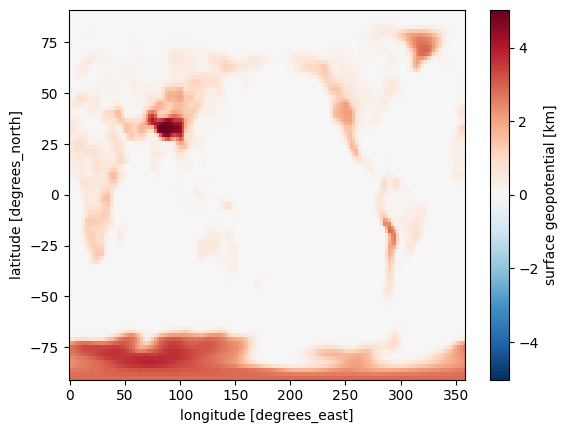

In [22]:
height.plot()

그래프의 모양을 더 세밀하게 제어하고 싶다면, `matplotlib`의 기능을 사용할 수 있습니다.

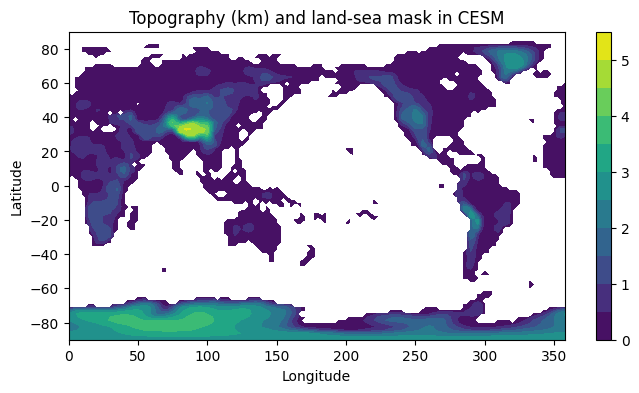

In [23]:
#  A filled contour plot of topography with contours every 500 m
lev = np.arange(0., 6., 0.5)
fig1, ax1 = plt.subplots(figsize=(8,4))
# Here we are masking the data to exclude points where the land fraction is zero (water only)
cax1 = ax1.contourf( height.lon, height.lat,
                    height.where(topo.LANDFRAC>0), levels=lev)
ax1.set_title('Topography (km) and land-sea mask in CESM')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
cbar1 = fig1.colorbar(cax1)

2도 해상도에서는 태평양 섬들과 같은 더 작은 지형적 특징들도 많이 볼 수 있습니다. 모델에는 각 격자점마다 토지 피복률(fractional land cover)이 주어집니다.

여기서는 육지-해양 마스크(land-sea mask) 자체를 그려서 물이 '조금이라도' 있는 곳을 확인해 봅시다:

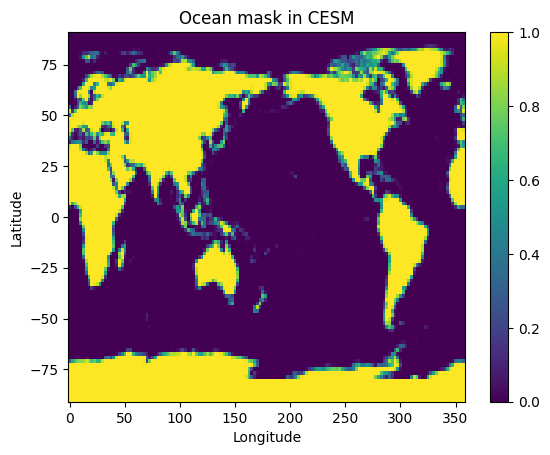

In [24]:
fig2, ax2 = plt.subplots()
cax2 = ax2.pcolormesh( topo.lon, topo.lat, topo.LANDFRAC )
ax2.set_title('Ocean mask in CESM')
ax2.set_xlabel('Longitude'); ax2.set_ylabel('Latitude')
cbar2 = fig2.colorbar(cax2);

### 더 나은 지도 만들기

이러한 플롯(plot)들을 만들 때, 우리는 어떤 지도 투영법(map projection)도 사용하지 않고 단순히 위경도 배열(lat-lon array)을 플롯했다는 점을 알 수 있습니다.

더 나은 지도를 만드는 데 사용할 수 있는 좋은 도구들이 있습니다. 이 내용은 다음 기회에 다루도록 하겠습니다. 하지만 미리 살펴보고 싶다면 다음을 확인해보세요:

<http://scitools.org.uk/cartopy/>

## 해양 경계 조건

해양과 대기와의 상호작용에 대한 정보가 담긴 다른 파일을 구글 드라이브에서 불러와 봅시다.

In [25]:
# 이 셀은 이제 파일을 업로드하는 대신, 구글 드라이브 경로를 사용합니다. 드라이브가 마운트되었는지 확인하세요.

In [27]:
local_file_name = "/content/drive/MyDrive/testdata/pop_frc.1x1d.090130.nc"

#decode_times 수정함 false로
som_input = xr.open_dataset(local_file_name, decode_times=False)
som_input

<xarray.Dataset> Size: 26MB
Dimensions:  (lat: 180, lon: 360, time: 12)
Coordinates:
  * time     (time) float32 48B 14.0 46.0 74.0 105.0 ... 258.0 288.0 319.0 349.0
Dimensions without coordinates: lat, lon
Data variables:
    area     (lat, lon) float64 518kB ...
    mask     (lat, lon) int32 259kB ...
    yc       (lat) float32 720B ...
    xc       (lon) float32 1kB ...
    S        (time, lat, lon) float32 3MB ...
    T        (time, lat, lon) float32 3MB ...
    U        (time, lat, lon) float32 3MB ...
    V        (time, lat, lon) float32 3MB ...
    dhdx     (time, lat, lon) float32 3MB ...
    dhdy     (time, lat, lon) float32 3MB ...
    hblt     (time, lat, lon) float32 3MB ...
    qdp      (time, lat, lon) float32 3MB ...
Attributes:
    creation_date:  Fri Jan 30 10:22:53 MST 2009
    comment:        This data is on a standard 1x1d grid.
    calendar:       standard
    author:         D. Bailey
    note3:          qdp is computed from depth summed ocean column
    note2:          all fields interpolated to T-grid
    note1:          fields computed from 20-yr monthly means from pop
    description:    Input data for DOCN7 mixed layer model from b40.999
    source:         pop_frc.ncl
    conventions:    CCSM data model domain description
    title:          Monthly averaged ocean forcing from POP output

해양 및 해빙 모델은 대기 모델과 다른 격자(grid)를 사용합니다 (2도 해상도 대신 1도 해상도).

이제 **연평균 해양 외부 열 플럭스(heat flux)**를 살펴보겠습니다.

이는 우리가 방금 열었던 데이터셋의 `qdp` 필드에 저장되어 있습니다.

CESM의 부호 규약(sign convention)은 `qdp > 0`일 때 **열이 해양으로 유입(inflow)된다는 것**입니다. 우리는 해양에서 대기로 나가는 열을 플롯(plot)하기 위해 부호를 변경할 것입니다 (이는 보다 대기 중심적인 관점입니다).

In [28]:
som_input.qdp

<xarray.DataArray 'qdp' (time: 12, lat: 180, lon: 360)> Size: 3MB
[777600 values with dtype=float32]
Coordinates:
  * time     (time) float32 48B 14.0 46.0 74.0 105.0 ... 258.0 288.0 319.0 349.0
Dimensions without coordinates: lat, lon
Attributes:
    spatial_op:  Bilinear remapping: 1st order: destarea: NCL: ./map_gx1v5_to...

안타깝게도, 여기서는 메타데이터가 그다지 유용하지 않은 경우입니다. 변수 `qdp`가 실제로 무엇인지, 또는 그 단위가 무엇인지에 대한 텍스트 설명이 없습니다. (실제로는 W m$^{-2}$ 단위입니다)

12 x 180 x 360개의 데이터 포인트가 있음을 알 수 있습니다. 각 역월(calendar month)마다 180 x 360 격자가 하나씩 있습니다!

이제 각 지점에서 연간 평균을 구할 것입니다.

여기서는 `xarray`의 강력한 기능을 활용하여 시간 차원(time dimension)에 대한 평균을 계산할 것입니다. 이렇게 하면 위도 180개 지점, 경도 360개 지점으로 구성된 단일 격자(grid)를 얻게 됩니다:

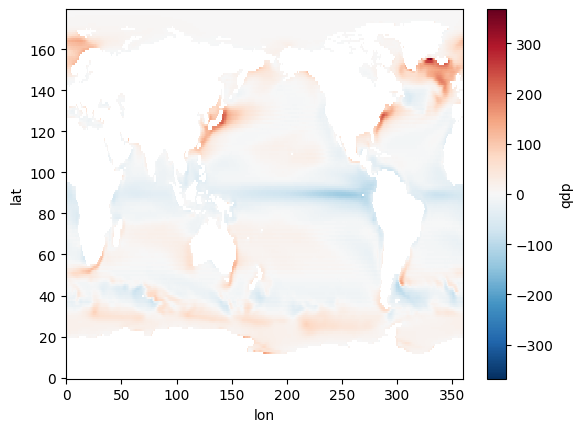

In [29]:
(-som_input.qdp.mean(dim='time')).plot()

이제 연평균 열 플럭스(q-flux)의 멋진 플롯을 그리세요.

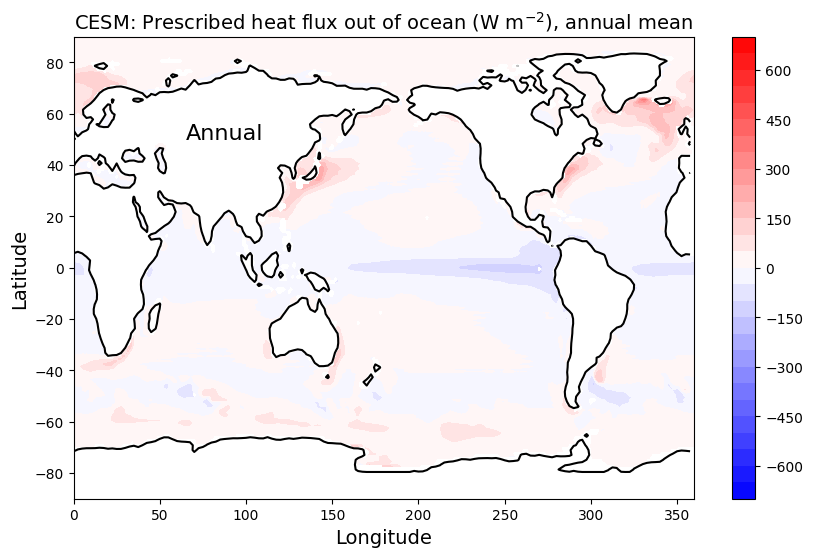

In [30]:
#  We can always set a non-standard size for our figure window
fig3, ax3 = plt.subplots(figsize=(10, 6))
lev = np.arange(-700., 750., 50.)
cax3 = ax3.contourf(som_input.xc, som_input.yc,
                    -som_input.qdp.mean(dim='time'),
                    levels=lev, cmap=plt.cm.bwr)
cbar3 = fig3.colorbar(cax3)
ax3.set_title( 'CESM: Prescribed heat flux out of ocean (W m$^{-2}$), annual mean',
              fontsize=14 )
ax3.set_xlabel('Longitude', fontsize=14)
ax3.set_ylabel('Latitude', fontsize=14)
ax3.text(65, 50, 'Annual', fontsize=16 )
ax3.contour(topo.lon, topo.lat, topo.LANDFRAC, levels=[0.5], colors='k');

여기 모든 공간 구조를 주목하세요:

-   적도, 특히 동태평양에서 많은 열이 해양으로 유입됩니다.
-   붉은색 고온 지점(핫스팟)들은 해양에서 많은 열이 방출되는 곳을 보여줍니다.
-   이러한 고온 지점들은 아시아와 북미 대륙 동쪽 해안 부근의 중위도 해역을 포함합니다.
-   그리고 북대서양 북부도 포함됩니다.

**이 모든 공간 구조는 우리가 여기서 모델링하고 있지 않은 해양 순환에 의해 결정됩니다.** 대신, 우리는 이러한 열속(heat flux) 패턴을 대기로의 입력으로 지정하고 있습니다.

이 패턴은 일 년 내내 변화합니다. 이 그림을 만들기 위해 모든 달을 평균했음을 기억하세요. 우리는 특정 한 달치만 살펴보고 싶을 수도 있습니다:

In [31]:
# select by month index (0 through 11)
som_input.qdp.isel(time=0)

<xarray.DataArray 'qdp' (lat: 180, lon: 360)> Size: 259kB
array([[      nan,       nan,       nan, ...,       nan,       nan,       nan],
       [      nan,       nan,       nan, ...,       nan,       nan,       nan],
       [      nan,       nan,       nan, ...,       nan,       nan,       nan],
       ...,
       [-5.75126 , -5.742314, -5.734764, ..., -5.792866, -5.774798, -5.761612],
       [-5.533446, -5.537023, -5.540624, ..., -5.522859, -5.526363, -5.529893],
       [-5.31631 , -5.314115, -5.311888, ..., -5.322703, -5.320605, -5.318473]],
      dtype=float32)
Coordinates:
    time     float32 4B 14.0
Dimensions without coordinates: lat, lon
Attributes:
    spatial_op:  Bilinear remapping: 1st order: destarea: NCL: ./map_gx1v5_to...

In [32]:
#  select by array slicing (but for this you have to know the axis order!)
som_input.qdp[0,:,:]

<xarray.DataArray 'qdp' (lat: 180, lon: 360)> Size: 259kB
array([[      nan,       nan,       nan, ...,       nan,       nan,       nan],
       [      nan,       nan,       nan, ...,       nan,       nan,       nan],
       [      nan,       nan,       nan, ...,       nan,       nan,       nan],
       ...,
       [-5.75126 , -5.742314, -5.734764, ..., -5.792866, -5.774798, -5.761612],
       [-5.533446, -5.537023, -5.540624, ..., -5.522859, -5.526363, -5.529893],
       [-5.31631 , -5.314115, -5.311888, ..., -5.322703, -5.320605, -5.318473]],
      dtype=float32)
Coordinates:
    time     float32 4B 14.0
Dimensions without coordinates: lat, lon
Attributes:
    spatial_op:  Bilinear remapping: 1st order: destarea: NCL: ./map_gx1v5_to...

여기서 우리는 변수 이름 뒤에 `[0,:,:]`를 지정하여 첫 번째 달(1월)만 얻었습니다. 이것은 배열을 *슬라이싱*(slicing)하거나 *인덱싱*(indexing)한다고 불립니다. 우리는 "0번 월에 해당하는 모든 것을 달라"고 말하는 것입니다. 이제 플롯을 만드세요:

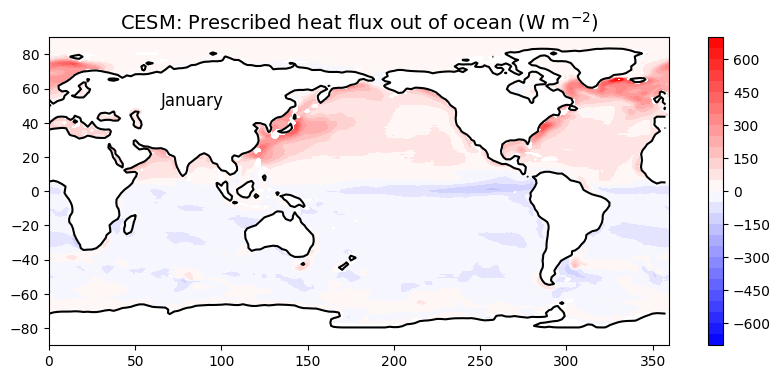

In [33]:
fig4, ax4 = plt.subplots(figsize=(10,4))
cax4 = ax4.contourf( som_input.xc, som_input.yc,
                    -som_input.qdp.isel(time=0),
                      levels=lev, cmap=plt.cm.bwr)
cbar4 = plt.colorbar(cax4)
ax4.set_title( 'CESM: Prescribed heat flux out of ocean (W m$^{-2}$)',
              fontsize=14 )
ax3.set_xlabel('Longitude', fontsize=14)
ax3.set_ylabel('Latitude', fontsize=14)
ax4.text(65, 50, 'January', fontsize=12 );
ax4.contour(topo.lon, topo.lat, topo.LANDFRAC, levels=[0.5], colors='k');

xarray를 사용하여 데이터셋을 다양하게 분할하고 분석하는 방법에 대한 더 많은 도움이 필요하시면, 다음 온라인 문서를 참조하세요:

http://xarray.pydata.org

## "산업화 이전" 대조군 실험

저희의 대조군 실험은 대기 조성에 인간에 의해 유의미한 변화가 발생하기 전 시기를 의미하는 "산업화 이전 시대"의 기후를 시뮬레이션하도록 설정되었습니다. 명목상 1850년을 기준으로 합니다.

이 대조군 실험의 결과물은 위에서 언급한 것과 동일한 데이터 서버에서 확인할 수 있습니다. `cpl_1850_f19`라는 폴더를 찾아보세요. (여기서 `cpl`은 상호작용하는 해양을 포함하는 "결합 모델(coupled model)"을 의미하며, 1850은 산업화 이전 조건을 나타내고, `f19`는 2도 수평 격자 해상도를 나타내는 코드입니다.)

각 활성 모델 구성 요소에 대한 출력 파일이 있습니다:

- 대기
- 해양
- 해빙
- 육상 표면

이 모델은 각 구성 요소에 대한 **월별 평균** 출력 파일을 생성합니다. 저희는 개별 월의 데이터셋을 불러올 수 있지만, 전체 결과물을 포함하는 크고 **결합된(concatenated)** 파일도 제공됩니다.

대기 파일을 살펴보겠습니다. 이 파일의 이름은 다음과 같습니다:

`cpl_1850_f19.cam.h0.nc`

(`.nc` 파일 확장자는 NetCDF 형식을 나타내는 데 사용됩니다.)

In [34]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [36]:
gdrive_file_path = "/content/drive/MyDrive/testdata/cpl_1850_f19.cam.h0.nc"
atm_control = xr.open_dataset(gdrive_file_path, decode_times=False)
atm_control

<xarray.Dataset> Size: 12GB
Dimensions:       (lev: 26, ilev: 27, time: 240, slat: 95, nbnd: 2, lat: 96,
                   lon: 144, slon: 144)
Coordinates:
  * lev           (lev) float64 208B 3.545 7.389 13.97 ... 929.6 970.6 992.6
  * ilev          (ilev) float64 216B 2.194 4.895 9.882 ... 956.0 985.1 1e+03
  * time          (time) float64 2kB 31.0 59.0 90.0 ... 7.269e+03 7.3e+03
  * slat          (slat) float64 760B -89.05 -87.16 -85.26 ... 85.26 87.16 89.05
  * lat           (lat) float64 768B -90.0 -88.11 -86.21 ... 86.21 88.11 90.0
  * lon           (lon) float64 1kB 0.0 2.5 5.0 7.5 ... 350.0 352.5 355.0 357.5
  * slon          (slon) float64 1kB -1.25 1.25 3.75 6.25 ... 351.2 353.8 356.2
Dimensions without coordinates: nbnd
Data variables: (12/128)
    hyam          (lev) float64 208B ...
    hybm          (lev) float64 208B ...
    hyai          (ilev) float64 216B ...
    hybi          (ilev) float64 216B ...
    P0            float64 8B ...
    date          (time) int32 960B ...
    ...            ...
    VTH3d         (time, ilev, lat, lon) float32 358MB ...
    VU            (time, lev, lat, lon) float32 345MB ...
    VV            (time, lev, lat, lon) float32 345MB ...
    W2d           (time, lat, lon) float32 13MB ...
    WTH3d         (time, ilev, lat, lon) float32 358MB ...
    Z3            (time, lev, lat, lon) float32 345MB ...
Attributes: (12/13)
    Conventions:               CF-1.0
    source:                    CAM
    case:                      cpl_1850_f19
    title:                     UNSET
    logname:                   br546577
    host:                      snow-30.rit.alba
    ...                        ...
    revision_Id:               $Id$
    initial_file:              b40.1850.track1.2deg.003.cam.i.0501-01-01-0000...
    topography_file:           /data/rose_scr/cesm_inputdata/atm/cam/topo/USG...
    history:                   Tue Feb 26 17:17:15 2019: ncrcat atm/hist/cpl_...
    NCO:                       4.6.8
    nco_openmp_thread_number:  1

다양한 것들입니다! 이것들은 모두 모델 시뮬레이션의 일부로 계산되는 다양한 양들입니다. **모든 양은 월평균을 나타냅니다**.

특정 변수에 대해 더 자세한 정보를 원하십니까?

In [37]:
atm_control.co2vmr

<xarray.DataArray 'co2vmr' (time: 240)> Size: 2kB
[240 values with dtype=float64]
Coordinates:
  * time     (time) float64 2kB 31.0 59.0 90.0 ... 7.239e+03 7.269e+03 7.3e+03
Attributes:
    long_name:  co2 volume mixing ratio

이것은 대기 중 CO$_2$의 양입니다 (약 285 부피 백만분율). 이 값은 이 시뮬레이션에서 사전에 정해져 있으며 변경되지 않습니다.

`xarray.DataArray` 객체의 좋은 점 중 하나는 간단한 산술 연산을 수행할 수 있다는 것입니다 (위 설명에서 이미 여러 예시를 보았습니다). 예를 들어, CO$_2$ 양의 단위를 ppm으로 변경합니다:

In [38]:
atm_control.co2vmr * 1E6

<xarray.DataArray 'co2vmr' (time: 240)> Size: 2kB
array([284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7,
       284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7,
       284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7,
       284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7,
       284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7,
       284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7,
       284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7,
       284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7,
       284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7,
       284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7,
       284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7,
       284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7,
       284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7,
       284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7,
       284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7,
       284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7,
       284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7,
       284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7,
       284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7,
       284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7,
       284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7,
       284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7,
       284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7,
       284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7,
       284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7,
       284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7, 284.7,
       284.7, 284.7, 284.7, 284.7, 284.7, 284.7])
Coordinates:
  * time     (time) float64 2kB 31.0 59.0 90.0 ... 7.239e+03 7.269e+03 7.3e+03
Attributes:
    long_name:  co2 volume mixing ratio

여기 또 다른 변수가 있습니다:

In [39]:
atm_control.SOLIN

<xarray.DataArray 'SOLIN' (time: 240, lat: 96, lon: 144)> Size: 13MB
[3317760 values with dtype=float32]
Coordinates:
  * time     (time) float64 2kB 31.0 59.0 90.0 ... 7.239e+03 7.269e+03 7.3e+03
  * lat      (lat) float64 768B -90.0 -88.11 -86.21 -84.32 ... 86.21 88.11 90.0
  * lon      (lon) float64 1kB 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
Attributes:
    Sampling_Sequence:  rad_lwsw
    units:              W/m2
    long_name:          Solar insolation
    cell_methods:       time: mean

이것은 유입되는 태양 복사(Solar Radiation), 즉 **일사량(Insolation)**인 것으로 보이며, (240,96,144)의 형태는 240개월, 96개의 위도 지점, 그리고 144개의 경도 지점으로 구성되어 있음을 의미합니다.

## 연습 문제: 시간 평균 취하기

- `SOLIN` 필드의 **시간 평균**을 계산하세요. 그 결과를 새로운 변수로 저장하세요.
- 결과로 생성된 데이터 배열의 **차원**은 어떻게 되나요? 이 양(quantity)을 시각화하기에 좋은 방법은 무엇일까요?

In [41]:
atm_control.SOLIN.mean(dim='time')

<xarray.DataArray 'SOLIN' (lat: 96, lon: 144)> Size: 55kB
array([[172.81734, 172.81734, 172.81734, ..., 172.81734, 172.81734,
        172.81734],
       [173.0204 , 173.0204 , 173.02022, ..., 173.01988, 173.02003,
        173.02028],
       [173.62914, 173.62895, 173.62877, ..., 173.62932, 173.6288 ,
        173.62898],
       ...,
       [172.12259, 172.123  , 172.123  , ..., 172.12276, 172.12286,
        172.12274],
       [171.51128, 171.51137, 171.5114 , ..., 171.51158, 171.51155,
        171.5115 ],
       [171.30817, 171.30817, 171.30817, ..., 171.30817, 171.30817,
        171.30817]], dtype=float32)
Coordinates:
  * lat      (lat) float64 768B -90.0 -88.11 -86.21 -84.32 ... 86.21 88.11 90.0
  * lon      (lon) float64 1kB 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
Attributes:
    Sampling_Sequence:  rad_lwsw
    units:              W/m2
    long_name:          Solar insolation
    cell_methods:       time: mean

## 실습: 시간 평균 일사량(Insolation) 그리기

1. 위에서 저장한 변수를 사용하여 시간 평균 일사량(Insolation)을 레이블이 잘 표시된 플롯으로 만드세요.
2. 데이터의 차원(dimensionality)을 **더 줄이고**, 해당 정보를 다른 방식으로 플롯으로 나타낼 수 있는 방법이 있을까요?

데이터 배열(data array)에서 원하는 수의 명명된 차원(named dimension)에 걸쳐 `.mean()` 연산을 적용할 수 있다는 점을 기억하세요.

## 대조군 실행과 관측된 에너지 수지 비교

지금까지 우리의 연구는 관측된 **연평균, 전 지구 평균 에너지 수지** 그림을 지침으로 삼아 진행되었음을 상기하십시오:


![관측된 전 지구 에너지 수지](http://www.atmos.albany.edu/facstaff/brose/classes/ENV415_Spring2018/images/GlobalEnergyBudget.png)

## 연습 문제: 전 지구 평균을 계산하는 방법에 대한 고찰

이 수치들을 대조군 실행(control run)과 비교하기 위해, 우리는 데이터의 **전 지구 평균을 구해야 합니다.** **전 지구 평균**이란 무엇을 의미할까요?

이 노트를 계속 진행하기 전에, 다음 질문에 답해보세요:

**위도-경도 격자(latitude-longitude grid)의 각 데이터 포인트(data point)를 단순히 평균하는 것이 왜 합리적이지 않을까요?**

## 전 지구 평균 가중치 부여

전 지구 평균은 각 격자 셀의 면적에 따라 가중치를 부여해야 하며, 이 면적은 **위도의 코사인 값**에 비례합니다(그 이유를 아시겠나요?).

이를 xarray에서 다음과 같이 구현할 수 있습니다:


In [42]:
#  Take the cosine of latitude (first converting to radians)
coslat = np.cos(np.deg2rad(atm_control.lat))
coslat

<xarray.DataArray 'lat' (lat: 96)> Size: 768B
array([6.12323400e-17, 3.30633693e-02, 6.60905843e-02, 9.90455303e-02,
       1.31892171e-01, 1.64594590e-01, 1.97117027e-01, 2.29423920e-01,
       2.61479941e-01, 2.93250037e-01, 3.24699469e-01, 3.55793847e-01,
       3.86499169e-01, 4.16781860e-01, 4.46608807e-01, 4.75947393e-01,
       5.04765538e-01, 5.33031729e-01, 5.60715057e-01, 5.87785252e-01,
       6.14212713e-01, 6.39968541e-01, 6.65024572e-01, 6.89353409e-01,
       7.12928448e-01, 7.35723911e-01, 7.57714870e-01, 7.78877279e-01,
       7.99187997e-01, 8.18624815e-01, 8.37166478e-01, 8.54792713e-01,
       8.71484244e-01, 8.87222819e-01, 9.01991230e-01, 9.15773327e-01,
       9.28554038e-01, 9.40319390e-01, 9.51056516e-01, 9.60753676e-01,
       9.69400266e-01, 9.76986831e-01, 9.83505075e-01, 9.88947871e-01,
       9.93309266e-01, 9.96584493e-01, 9.98769969e-01, 9.99863305e-01,
       9.99863305e-01, 9.98769969e-01, 9.96584493e-01, 9.93309266e-01,
       9.88947871e-01, 9.83505075e-01, 9.76986831e-01, 9.69400266e-01,
       9.60753676e-01, 9.51056516e-01, 9.40319390e-01, 9.28554038e-01,
       9.15773327e-01, 9.01991230e-01, 8.87222819e-01, 8.71484244e-01,
       8.54792713e-01, 8.37166478e-01, 8.18624815e-01, 7.99187997e-01,
       7.78877279e-01, 7.57714870e-01, 7.35723911e-01, 7.12928448e-01,
       6.89353409e-01, 6.65024572e-01, 6.39968541e-01, 6.14212713e-01,
       5.87785252e-01, 5.60715057e-01, 5.33031729e-01, 5.04765538e-01,
       4.75947393e-01, 4.46608807e-01, 4.16781860e-01, 3.86499169e-01,
       3.55793847e-01, 3.24699469e-01, 2.93250037e-01, 2.61479941e-01,
       2.29423920e-01, 1.97117027e-01, 1.64594590e-01, 1.31892171e-01,
       9.90455303e-02, 6.60905843e-02, 3.30633693e-02, 6.12323400e-17])
Coordinates:
  * lat      (lat) float64 768B -90.0 -88.11 -86.21 -84.32 ... 86.21 88.11 90.0
Attributes:
    long_name:  latitude
    units:      degrees_north

In [43]:
#  And divide by its mean value
weight_factor = coslat / coslat.mean(dim='lat')
#  Want to see what we just created?
weight_factor

<xarray.DataArray 'lat' (lat: 96)> Size: 768B
array([9.72048516e-17, 5.24872953e-02, 1.04917196e-01, 1.57232372e-01,
       2.09375617e-01, 2.61289912e-01, 3.12918491e-01, 3.64204898e-01,
       4.15093052e-01, 4.65527308e-01, 5.15452516e-01, 5.64814085e-01,
       6.13558038e-01, 6.61631075e-01, 7.08980627e-01, 7.55554920e-01,
       8.01303024e-01, 8.46174915e-01, 8.90121527e-01, 9.33094803e-01,
       9.75047755e-01, 1.01593451e+00, 1.05571035e+00, 1.09433178e+00,
       1.13175659e+00, 1.16794383e+00, 1.20285394e+00, 1.23644875e+00,
       1.26869152e+00, 1.29954700e+00, 1.32898144e+00, 1.35696266e+00,
       1.38346006e+00, 1.40844466e+00, 1.43188916e+00, 1.45376790e+00,
       1.47405697e+00, 1.49273418e+00, 1.50977911e+00, 1.52517311e+00,
       1.53889936e+00, 1.55094285e+00, 1.56129040e+00, 1.56993071e+00,
       1.57685432e+00, 1.58205366e+00, 1.58552305e+00, 1.58725870e+00,
       1.58725870e+00, 1.58552305e+00, 1.58205366e+00, 1.57685432e+00,
       1.56993071e+00, 1.56129040e+00, 1.55094285e+00, 1.53889936e+00,
       1.52517311e+00, 1.50977911e+00, 1.49273418e+00, 1.47405697e+00,
       1.45376790e+00, 1.43188916e+00, 1.40844466e+00, 1.38346006e+00,
       1.35696266e+00, 1.32898144e+00, 1.29954700e+00, 1.26869152e+00,
       1.23644875e+00, 1.20285394e+00, 1.16794383e+00, 1.13175659e+00,
       1.09433178e+00, 1.05571035e+00, 1.01593451e+00, 9.75047755e-01,
       9.33094803e-01, 8.90121527e-01, 8.46174915e-01, 8.01303024e-01,
       7.55554920e-01, 7.08980627e-01, 6.61631075e-01, 6.13558038e-01,
       5.64814085e-01, 5.15452516e-01, 4.65527308e-01, 4.15093052e-01,
       3.64204898e-01, 3.12918491e-01, 2.61289912e-01, 2.09375617e-01,
       1.57232372e-01, 1.04917196e-01, 5.24872953e-02, 9.72048516e-17])
Coordinates:
  * lat      (lat) float64 768B -90.0 -88.11 -86.21 -84.32 ... 86.21 88.11 90.0
Attributes:
    long_name:  latitude
    units:      degrees_north

### 대안: 데이터셋에 이미 제공된 가중치 사용

많은 격자형 데이터셋에는 정확한 면적 가중치(area weighting)를 제공하는 필드가 이미 포함되어 있음을 알 수 있습니다.

CESM 출력의 경우, 해당 필드는 `gw`라고 불립니다.

In [44]:
weight_factor2 = atm_control.gw / atm_control.gw.mean(dim='lat')

In [45]:
weight_factor2

<xarray.DataArray 'gw' (lat: 96)> Size: 768B
array([0.00656136, 0.05248012, 0.10490285, 0.15721088, 0.209347  ,
       0.26125419, 0.31287572, 0.36415511, 0.41503631, 0.46546367,
       0.51538206, 0.56473688, 0.61347417, 0.66154063, 0.70888371,
       0.75545164, 0.80119349, 0.84605925, 0.88999985, 0.93296725,
       0.97491447, 1.01579563, 1.05556604, 1.09418219, 1.13160188,
       1.16778418, 1.20268952, 1.23627974, 1.2685181 , 1.29936936,
       1.32879977, 1.35677717, 1.38327095, 1.40825214, 1.43169343,
       1.45356918, 1.47385547, 1.49253013, 1.50957273, 1.52496463,
       1.538689  , 1.55073084, 1.56107698, 1.56971611, 1.57663877,
       1.5818374 , 1.58530632, 1.58704173, 1.58704173, 1.58530632,
       1.5818374 , 1.57663877, 1.56971611, 1.56107698, 1.55073084,
       1.538689  , 1.52496463, 1.50957273, 1.49253013, 1.47385547,
       1.45356918, 1.43169343, 1.40825214, 1.38327095, 1.35677717,
       1.32879977, 1.29936936, 1.2685181 , 1.23627974, 1.20268952,
       1.16778418, 1.13160188, 1.09418219, 1.05556604, 1.01579563,
       0.97491447, 0.93296725, 0.88999985, 0.84605925, 0.80119349,
       0.75545164, 0.70888371, 0.66154063, 0.61347417, 0.56473688,
       0.51538206, 0.46546367, 0.41503631, 0.36415511, 0.31287572,
       0.26125419, 0.209347  , 0.15721088, 0.10490285, 0.05248012,
       0.00656136])
Coordinates:
  * lat      (lat) float64 768B -90.0 -88.11 -86.21 -84.32 ... 86.21 88.11 90.0
Attributes:
    long_name:  gauss weights

### 전 지구적, 시간 평균 일사량 계산

In [46]:
#  Compute the global, time average insolation using our two different weight factors
#  Notice that we can apply the .mean() operation simultaneously over several dimensions!
(atm_control.SOLIN * weight_factor).mean(dim=('time', 'lon', 'lat'))
(atm_control.SOLIN * weight_factor2).mean(dim=('time', 'lon', 'lat'))

<xarray.DataArray ()> Size: 8B
array(340.30586262)
Attributes:
    Sampling_Sequence:  rad_lwsw
    units:              W/m2
    cell_methods:       time: mean

이 두 값은 모두 340.3에 매우 가까워야 합니다.

이 값은 W m$^{-2}$ 단위를 사용하는 전 지구 평균 일사량입니다.

## 연습문제: 전 지구 평균 시계열 그리기

통제 실험(control simulation)에서 **전 지구 평균 표면 온도**의 **시계열**을 그리시오.

데이터셋에서 표면 온도는 `'TS'`로 불립니다.

x축에 시간을 두어 전 지구 평균 `TS`의 플롯을 작성하시오. *위에서 논의된 바와 같이, 전 지구 평균이 적절하게 가중(weighted)되었는지 확인하세요.*

In [ ]:
TSglobal = (atm_control.TS * weight_factor).mean(dim=('lon','lat'))
TSglobal

<xarray.DataArray (time: 240)> Size: 2kB
array([285.72898682, 285.49401299, 286.27904211, 287.41386972,
       288.27003459, 289.09844124, 289.31503214, 289.14779089,
       288.48446959, 287.43825379, 286.30005108, 285.4822201 ,
       285.52587345, 285.70978305, 286.51907145, 287.39663259,
       288.43036138, 289.27239843, 289.49334981, 289.2270018 ,
       288.56324199, 287.45506122, 286.36152137, 285.68297431,
       285.64115059, 286.02903336, 286.66517814, 287.57771538,
       288.5114103 , 289.15209553, 289.58562369, 289.51435914,
       288.63846921, 287.62349476, 286.53952026, 285.71252715,
       285.37900612, 285.68432086, 286.42280295, 287.53516323,
       288.52624785, 289.36963343, 289.70397247, 289.38845523,
       288.56153317, 287.61485545, 286.58915711, 286.02656523,
       285.6876509 , 285.80444733, 286.77147652, 287.6000804 ,
       288.47466646, 289.30900949, 289.54640526, 289.27115635,
       288.60119008, 287.59500245, 286.47227001, 285.94176738,
       285.50164567, 286.04132674, 286.69947865, 287.55425306,
       288.51615009, 289.240104  , 289.53590774, 289.28245353,
       288.4526808 , 287.4798987 , 286.32498383, 285.64667703,
       285.53638463, 285.85984702, 286.48845149, 287.36777131,
       288.34274536, 289.12537178, 289.46937558, 289.41924937,
...
       288.66900064, 289.31232564, 289.71310487, 289.44685327,
       288.71353149, 287.64889492, 286.73669719, 285.88254536,
       285.93817813, 286.05794423, 286.63321729, 287.70598391,
       288.73680573, 289.24659283, 289.6523757 , 289.31808086,
       288.48550632, 287.3645237 , 286.46258606, 285.84163214,
       285.38701708, 285.81055181, 286.62392007, 287.61150279,
       288.43171261, 289.12028406, 289.4036265 , 289.16730135,
       288.38935887, 287.26655169, 286.38843632, 285.56931263,
       285.34475367, 285.70284077, 286.53049737, 287.37161667,
       288.31928104, 288.98644684, 289.40416911, 289.18403561,
       288.53231764, 287.34320592, 286.2297441 , 285.59461117,
       285.26074355, 285.66897701, 286.59709518, 287.33668608,
       288.406746  , 289.1222094 , 289.49321334, 289.45735775,
       288.57569049, 287.47754096, 286.72450398, 286.1310169 ,
       285.91070994, 286.24678875, 286.69563966, 287.79494103,
       288.87472496, 289.55314895, 289.76593884, 289.43723345,
       288.66578906, 287.63208369, 286.60205948, 286.15867963,
       285.85908296, 285.81623454, 286.62021016, 287.67040383,
       288.6576103 , 289.17532218, 289.57529292, 289.43251147,
       288.62634617, 287.4513469 , 286.34874094, 285.93312728])
Coordinates:
  * time     (time) float64 2kB 31.0 59.0 90.0 ... 7.239e+03 7.269e+03 7.3e+03
Attributes:
    cell_methods:  time: mean

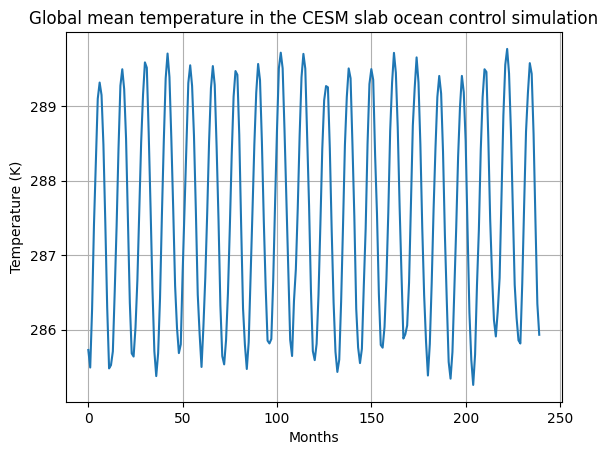

In [ ]:
# Note we could just do a TSglobal.plot() here!
#  But this is an example of using matplotlib directly to get more control over the figure

fig, ax = plt.subplots()
ax.plot(TSglobal)
ax.set_xlabel('Months')
ax.set_ylabel('Temperature (K)')
ax.grid()
ax.set_title('Global mean temperature in the CESM slab ocean control simulation');

### 논의점

이 그래프에서 무엇을 보셨나요? 전지구 평균 온도(global average temperature)가 왜 이와 같이 나타나는지에 대한 생각이 있으신가요?

또한, 이 시뮬레이션(simulation)에서 **시간 평균(time average)** 전지구 평균 지표면 온도(global-average surface temperature)는 얼마인가요?

In [ ]:
TSglobal.mean(dim='time')

<xarray.DataArray ()> Size: 8B
array(287.54590571)
Attributes:
    cell_methods:  time: mean

### 모델 출력에서 복사 플럭스 (radiative fluxes) 찾기

이제 전지구 평균과 시간 평균을 계산할 수 있으니, 일부 에너지 수지(energy budget) 값을 관측값과 비교할 수 있습니다.

모델 출력에는 복사 플럭스에 대한 많은 진단 자료(diagnostics)가 포함되어 있습니다. 여기 적절한 출력 필드(output fields)를 찾는 데 도움이 될 CESM 명명 규칙(naming conventions)이 있습니다:

- 이름이 `'F'`로 시작하는 모든 변수는 일종의 **에너지 플럭스**입니다.
- 대부분 네 글자로 된 코드를 가지며, 예: `'FLNT'`
- `'FL'`은 **장파 플럭스**(longwave flux)를 의미합니다 (즉, 지구 복사).
- `'FS'`는 **단파 플럭스**(shortwave flux)를 의미합니다 (즉, 태양 복사).
- 세 번째 글자는 플럭스의 **방향**을 나타냅니다:
    - `'U'` = 상향
    - `'D'` = 하향
    - `'N'` = 순(net)
- 네 번째 글자는 플럭스의 **위치**를 나타냅니다:
    - `'T'` = 대기 상단(top of atmosphere)
    - `'S'` = 지표면(surface)
- 따라서 `'FLNT'`는 '대기 상단의 순 장파 플럭스(net longwave flux at the top of atmosphere)'를 의미하며, 이는 곧 외향 장파 복사(outgoing longwave radiation) 또는 OLR입니다.

이 값들이 모두 240 x 96 x 144임을 알 수 있을 것입니다 -- 즉, 시뮬레이션의 매월에 대한 2차원 격자(grid)입니다.

In [47]:
atm_control.FLNT

<xarray.DataArray 'FLNT' (time: 240, lat: 96, lon: 144)> Size: 13MB
[3317760 values with dtype=float32]
Coordinates:
  * time     (time) float64 2kB 31.0 59.0 90.0 ... 7.239e+03 7.269e+03 7.3e+03
  * lat      (lat) float64 768B -90.0 -88.11 -86.21 -84.32 ... 86.21 88.11 90.0
  * lon      (lon) float64 1kB 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
Attributes:
    Sampling_Sequence:  rad_lwsw
    units:              W/m2
    long_name:          Net longwave flux at top of model
    cell_methods:       time: mean

## 연습 문제: 행성 에너지 수지 항 계산 이거 시험내신다고함


다음 네 가지 양의 연평균, 전지구 평균을 계산하세요.

1.  입사 태양 복사 (Incoming solar radiation) (또는 일사량 (Insolation))
2.  흡수 태양 복사 (Absorbed Solar Radiation, ASR)
3.  행성 반사율 (Planetary Albedo) *(이것이 나가는 태양 복사량 대 들어오는 태양 복사량의 **비율**임을 기억하세요)*
4.  외향 장파 복사 (Outgoing Longwave Radiation, OLR)

여러분의 결과를 관측값과 간략하게 비교하세요.

In [50]:
# 1. 입사 태양 복사 (Incoming solar radiation) (또는 일사량 (Insolation)) 계산
# 이미 생성된 weight_factor (lat 코사인) 또는 weight_factor2 (가우스 가중치)를 사용합니다.
# 두 가지 방법 모두 거의 동일한 결과를 제공합니다.

# weight_factor를 사용하여 전 지구 평균, 시간 평균 일사량 계산
insolation_global_mean = (atm_control.SOLIN * weight_factor).mean(dim=('time', 'lon', 'lat'))

print(f"모델에서 계산된 전 지구 평균 입사 태양 복사 (SOLIN): {insolation_global_mean.item():.2f} W/m2")
print(f"관측된 전 지구 에너지 수지 그림의 입사 태양 복사: 340 W/m2")
print(f"모델 값과 관측 값의 차이: {insolation_global_mean.item() - 340.0:.2f} W/m2")

# 2. 흡수 태양 복사 (Absorbed Solar Radiation, ASR) 계산
# FSWCF - 구름 없는 하늘의 순 단파 복사 (net shortwave flux at surface, clear sky)
# FSWCRE - 구름 복사 효과에 의한 단파 복사 (shortwave cloud radiative effect)
# FSDS - 지표면에 도달하는 하향 단파 복사 (downwelling shortwave flux at surface)
# FSNS - 지표면의 순 단파 복사 (net shortwave flux at surface)
# FSNTOA - 대기 상단의 순 단파 복사 (net shortwave flux at top of atmosphere)

# ASR은 대기 상단의 순 단파 복사량입니다. 모델에서 FSNT 변수를 사용합니다.
# FSNT는 대기 상단으로 들어오는 태양 복사에서 반사되는 복사를 뺀 값입니다.

asr_global_mean = (atm_control.FSNT * weight_factor).mean(dim=('time', 'lon', 'lat'))

print(f"\n모델에서 계산된 전 지구 평균 흡수 태양 복사 (ASR): {asr_global_mean.item():.2f} W/m2")
print(f"관측된 전 지구 에너지 수지 그림의 흡수 태양 복사: 240 W/m2")
print(f"모델 값과 관측 값의 차이: {asr_global_mean.item() - 240.0:.2f} W/m2")

# 3. 행성 반사율 (Planetary Albedo) 계산
# 행성 반사율은 (들어오는 태양 복사 - 흡수 태양 복사) / 들어오는 태양 복사 입니다.
# 또는 모델에서는 대기 상단에서 반사되는 단파 복사 (FSNT_clear - FSNT) / SOLIN 로도 근사할 수 있습니다.
# FSNT_clear는 구름이 없는 경우의 순 단파 복사를 나타내는데, 여기서는 FSNT와 SOLIN을 사용하여 직접 계산합니다.
# 반사된 태양 복사 = SOLIN - ASR
reflected_solar_radiation = insolation_global_mean - asr_global_mean
planetary_albedo = reflected_solar_radiation / insolation_global_mean

print(f"\n모델에서 계산된 전 지구 평균 행성 반사율: {planetary_albedo.item():.3f}")
print(f"관측된 전 지구 에너지 수지 그림의 행성 반사율: 0.30 (반사된 태양 복사 100 W/m2 / 입사 태양 복사 340 W/m2)")
print(f"모델 값과 관측 값의 차이: {planetary_albedo.item() - (100/340):.3f}")

# 4. 외향 장파 복사 (Outgoing Longwave Radiation, OLR) 계산
# OLR은 대기 상단에서의 순 장파 복사량으로, 모델에서 FLNT 변수를 사용합니다.
# FLNT의 정의는 'Net longwave flux at top of model'이며, CESM의 부호 규칙에 따라 양수 값은 지구 밖으로 나가는 복사를 의미합니다.

olr_global_mean = (atm_control.FLNT * weight_factor).mean(dim=('time', 'lon', 'lat'))

print(f"\n모델에서 계산된 전 지구 평균 외향 장파 복사 (OLR): {olr_global_mean.item():.2f} W/m2")
print(f"관측된 전 지구 에너지 수지 그림의 외향 장파 복사: 240 W/m2")
print(f"모델 값과 관측 값의 차이: {olr_global_mean.item() - 240.0:.2f} W/m2")

모델에서 계산된 전 지구 평균 입사 태양 복사 (SOLIN): 340.33 W/m2
관측된 전 지구 에너지 수지 그림의 입사 태양 복사: 340 W/m2
모델 값과 관측 값의 차이: 0.33 W/m2

모델에서 계산된 전 지구 평균 흡수 태양 복사 (ASR): 234.21 W/m2
관측된 전 지구 에너지 수지 그림의 흡수 태양 복사: 240 W/m2
모델 값과 관측 값의 차이: -5.79 W/m2

모델에서 계산된 전 지구 평균 행성 반사율: 0.312
관측된 전 지구 에너지 수지 그림의 행성 반사율: 0.30 (반사된 태양 복사 100 W/m2 / 입사 태양 복사 340 W/m2)
모델 값과 관측 값의 차이: 0.018

모델에서 계산된 전 지구 평균 외향 장파 복사 (OLR): 234.22 W/m2
관측된 전 지구 에너지 수지 그림의 외향 장파 복사: 240 W/m2
모델 값과 관측 값의 차이: -5.78 W/m2


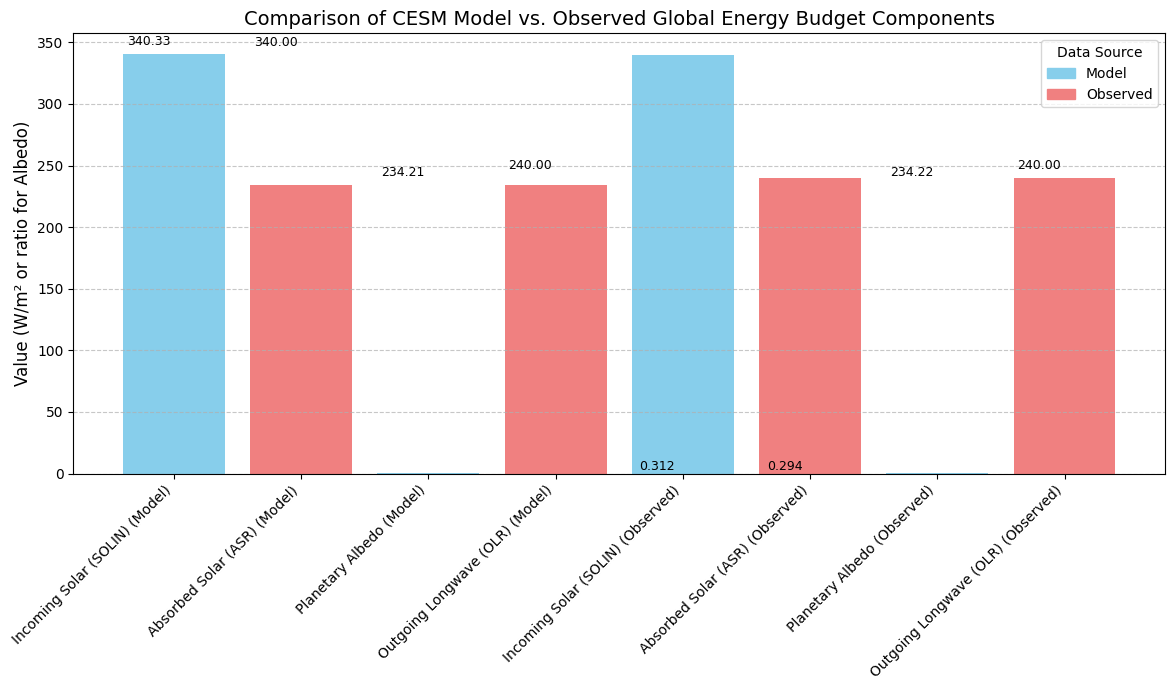

In [51]:
import matplotlib.pyplot as plt
import pandas as pd

# Calculate all values again to ensure they are available
insolation_global_mean = (atm_control.SOLIN * weight_factor).mean(dim=('time', 'lon', 'lat')).item()
asr_global_mean = (atm_control.FSNT * weight_factor).mean(dim=('time', 'lon', 'lat')).item()
reflected_solar_radiation = insolation_global_mean - asr_global_mean
planetary_albedo = reflected_solar_radiation / insolation_global_mean
olr_global_mean = (atm_control.FLNT * weight_factor).mean(dim=('time', 'lon', 'lat')).item()

# Observed values from the provided image (approximate)
observed_insolation = 340.0
observed_asr = 240.0
observed_reflected = 100.0 # From 340 total, 240 absorbed, so 100 reflected
observed_albedo = observed_reflected / observed_insolation # 100 / 340 = ~0.294
observed_olr = 240.0

# Prepare data for plotting
data = {
    'Component': ['Incoming Solar (SOLIN)', 'Absorbed Solar (ASR)', 'Planetary Albedo', 'Outgoing Longwave (OLR)'],
    'Model': [insolation_global_mean, asr_global_mean, planetary_albedo, olr_global_mean],
    'Observed': [observed_insolation, observed_asr, observed_albedo, observed_olr]
}
df_plot = pd.DataFrame(data)

# For easier plotting, melt the DataFrame
df_melted = df_plot.melt(id_vars='Component', var_name='Source', value_name='Value')

# Create the bar plot
plt.figure(figsize=(12, 7))
barplot = plt.bar(df_melted['Component'] + ' (' + df_melted['Source'] + ')', df_melted['Value'], color=['skyblue', 'lightcoral', 'skyblue', 'lightcoral', 'skyblue', 'lightcoral', 'skyblue', 'lightcoral'])

# Add values on top of the bars for numerical components (SOLIN, ASR, OLR)
for i, (component, model_val, obs_val) in enumerate(zip(df_plot['Component'], df_plot['Model'], df_plot['Observed'])):
    if component != 'Planetary Albedo': # Albedo is a ratio, plot directly
        plt.text(i*2 - 0.2, model_val + 5, f'{model_val:.2f}', ha='center', va='bottom', fontsize=9)
        plt.text(i*2 + 0.8, obs_val + 5, f'{obs_val:.2f}', ha='center', va='bottom', fontsize=9)
    else: # For Albedo, ensure two bars are labeled correctly
        plt.text(i*2 - 0.2, model_val + 0.01, f'{model_val:.3f}', ha='center', va='bottom', fontsize=9)
        plt.text(i*2 + 0.8, obs_val + 0.01, f'{obs_val:.3f}', ha='center', va='bottom', fontsize=9)

# Re-create legend handles and labels manually for clarity
legend_labels = ['Model', 'Observed']
legend_colors = ['skyblue', 'lightcoral']
legend_handles = [plt.Rectangle((0,0),1,1, color=color) for color in legend_colors]
plt.legend(legend_handles, legend_labels, title='Data Source')


plt.title('Comparison of CESM Model vs. Observed Global Energy Budget Components', fontsize=14)
plt.ylabel('Value (W/m² or ratio for Albedo)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 몇 가지 추가 정보

데이터를 계속 자유롭게 탐색해 보세요!

다른 많은 필드(장)들은 4차원입니다 (시간, 고도층, 위도, 경도).

예를 들어, 여기에는 모든 지점과 모든 월의 **기온**이 있습니다:

In [ ]:
atm_control.T

<xarray.DataArray 'T' (time: 240, lev: 26, lat: 96, lon: 144)> Size: 345MB
[86261760 values with dtype=float32]
Coordinates:
  * time     (time) float64 2kB 31.0 59.0 90.0 ... 7.239e+03 7.269e+03 7.3e+03
  * lev      (lev) float64 208B 3.545 7.389 13.97 23.94 ... 929.6 970.6 992.6
  * lat      (lat) float64 768B -90.0 -88.11 -86.21 -84.32 ... 86.21 88.11 90.0
  * lon      (lon) float64 1kB 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
Attributes:
    mdims:         1
    units:         K
    long_name:     Temperature
    cell_methods:  time: mean

    종종 우리는 **특정 장소와 시간**의 데이터를 샘플링(표집)하고 싶어 합니다. xarray는 이를 위한 간단한 방법들을 제공합니다.

예를 들어, 우리는 특정 위도 및 경도 위치(여기서는 뉴욕 올버니의 좌표입니다)로 **보간(interpolate)**할 수 있습니다:

In [ ]:
Tlocal = atm_control.T.interp(lat=42.75, lon=(360-73.8))
Tlocal

<xarray.DataArray 'T' (time: 240, lev: 26)> Size: 50kB
array([[231.55347435, 230.88840778, 225.30258457, ..., 268.2404776 ,
        269.52409576, 269.43490089],
       [228.10008728, 223.95615376, 221.31091049, ..., 274.1026815 ,
        275.9925309 , 275.95261742],
       [233.83040749, 227.64979877, 222.90131077, ..., 273.13557961,
        275.45856834, 276.13333687],
       ...,
       [232.50221451, 228.86013168, 225.24411854, ..., 285.83419807,
        288.1594445 , 287.90178192],
       [224.24851162, 221.39988674, 219.95343647, ..., 277.54828316,
        279.91035378, 279.59760986],
       [220.30998913, 218.22460804, 217.92282791, ..., 268.73481789,
        270.65231613, 270.98946404]])
Coordinates:
  * time     (time) float64 2kB 31.0 59.0 90.0 ... 7.239e+03 7.269e+03 7.3e+03
  * lev      (lev) float64 208B 3.545 7.389 13.97 23.94 ... 929.6 970.6 992.6
    lat      float64 8B 42.75
    lon      float64 8B 286.2
Attributes:
    mdims:         1
    units:         K
    long_name:     Temperature
    cell_methods:  time: mean

우리는 또한 **시간 인덱싱(time indexing)**을 사용하여 특정 연도와 월을 선택할 수 있습니다:

In [ ]:
#  The .sel notation mean "select" along the given coordinate
#  The string that follows is year-month. Our simulation begins in year 0001.
# The 'time' coordinate is currently a float, not a datetime object because decode_times=False was used.
# To select January of year 0020, we can use integer indexing.
# Year 0020 is the 20th year, so the index for January would be (20-1) * 12 = 228.
Tlocal.isel(time=228)  # Select January of year 0020 using integer index

<xarray.DataArray 'T' (lev: 26)> Size: 208B
array([226.31391743, 223.96027401, 224.27862999, 223.59100979,
       222.20726814, 218.60710827, 215.49681458, 212.77227413,
       212.51058559, 212.6287405 , 211.216777  , 209.88510956,
       210.29042641, 213.95152321, 220.14506561, 227.89859879,
       236.23803753, 244.60677494, 252.58280979, 259.93468857,
       265.52647949, 268.81354996, 270.64555557, 270.06114563,
       271.53999939, 272.07936562])
Coordinates:
  * lev      (lev) float64 208B 3.545 7.389 13.97 23.94 ... 929.6 970.6 992.6
    time     float64 8B 6.966e+03
    lat      float64 8B 42.75
    lon      float64 8B 286.2
Attributes:
    mdims:         1
    units:         K
    long_name:     Temperature
    cell_methods:  time: mean

이제, 예를 들어, 이 장소와 시간에 압력의 함수로 온도를 그려볼 수 있습니다:

In [ ]:
Tlocal.sel(time='0020-01').plot()

ValueError: could not convert string to float: np.str_('0020-01')

## 기여

이 노트북은 올버니 대학교(University at Albany)의 [브라이언 E. J. 로즈(Brian E. J. Rose)](https://www.atmos.albany.edu/facstaff/brose/)가 개발하고 유지보수하는 오픈 소스 교과서인 [The Climate Laboratory](https://brian-rose.github.io/ClimateLaboratoryBook)의 일부입니다.

이 자료는 [크리에이티브 커먼즈 저작자표시 4.0 국제 (CC BY 4.0)](https://creativecommons.org/licenses/by/4.0/) 라이선스에 따라 자유롭게 이용할 수 있도록 허가되었습니다.

이 자료와 [climlab 소프트웨어](https://github.com/climlab/climlab)의 개발은 브라이언 로즈(Brian Rose)에게 수여된 미국 국립과학재단(National Science Foundation)의 AGS-1455071 과제(award)를 통해 부분적으로 지원됩니다. 여기에 표현된 모든 의견, 연구 결과, 결론 또는 권고는 전적으로 저의 것이며, 반드시 미국 국립과학재단(National Science Foundation)의 견해를 반영하는 것은 아닙니다.